# Azizi lab
# Lingting Shi 1/6/2023
# Decipher analysis on GVHD project's all T cell data
# Raw counts

In [40]:
#!pip install scdecipher

In [41]:
import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scanpy as sc
import anndata
from pathlib import Path

In [43]:
import decipher as dc
dc.pl.activate_journal_quality()

In [71]:
# Paths — relative to this notebook's location (GVHD_Reproducibility-main/DecipherTCR/)
PROJECT_ROOT = Path('../..')

# Input paths
TCELL_ANN_SC_PATH     = PROJECT_ROOT / 'adata_file' / 'tcell_ann_sc.h5ad'

# Output paths — figures
FIGURES_SC_DIR        = PROJECT_ROOT / 'Figures' / 'Single_cell_figures'

FIGURES_TRA_DIR        = PROJECT_ROOT / 'Figures' / 'Trajectory_figures'

TCELL_ANN_SC_DC_PATH     = PROJECT_ROOT / 'adata_file' / 'tcell_ann_sc_dc.h5ad'

In [45]:
# Load in the anndata with doublet information
Tcell_sc = sc.read(TCELL_ANN_SC_PATH)
Tcell_sc

AnnData object with n_obs × n_vars = 38815 × 38012
    obs: 'PatientID', 'SampleID', 'FreshorFrozen', 'Days_post-Transplant', 'Tissue_Location', 'LPorIE', 'Enrichment Method', 'Pathological_grade_of_GVHD', 'Grade_num', 'GVHD_Grade_1', 'GVHD_Grade_2', 'GVHD_Grade_3', 'Transplant_Conditioning', 'Gender', 'DoT', 'Time_1stGVHD', 'Donor', 'Disease', 'GVHD_Prophylaxis_Regimen', 'Dates_from_Transplantation', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'is_doublet', 'leiden', 'leiden_0.15', 'B_doublet', 'Myeloid_doublet', 'Macrophage_doublet', 'Monocyte_doublet', 'Epithelial_doublet', 'Fibroblast_doublet', 'plasma_doublet2', 'if_doublet', 'T_cell_subsets'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'B_doublet_colors', 'Epithelial_doublet_colors', 'Fibroblast_doublet_colors', 'Macropha

In [46]:
Tcell_sc.obs['T_cell_subsets']

R096_Tc17_up_AAACCTGGTTGGAGGT-1    CD4+ central memory T cells
R096_Tc17_up_AAACCTGTCTATCCTA-1          CD8+ effector T cells
R096_Tc17_up_AAACGGGAGGATGCGT-1          CD8+ effector T cells
R096_Tc17_up_AAACGGGGTAAATGAC-1          CD8+ effector T cells
R096_Tc17_up_AAAGATGCAAACTGTC-1          CD8+ effector T cells
                                              ...             
UA41_TGTTCCGAGGACAGCT-1                  CD4+ effector T cells
UA41_TTAGGACGTTGTTTGG-1                                Low CD3
UA41_TTAGGACTCCCAAGAT-1                  CD4+ effector T cells
UA41_TTCGAAGTCCGCATCT-1                  CD4+ effector T cells
UA41_TTGCGTCCAAGAAAGG-1                  CD4+ effector T cells
Name: T_cell_subsets, Length: 38815, dtype: category
Categories (9, object): ['CD8+ effector T cells' < 'CD8+ cytotoxic unconventional T cells' < 'CD8+ tissue resident memory T cells' < 'CD8+ homeostatic unconventional T cells' ... 'CD4+ effector T cells' < 'CD4+ central memory T cells' < 'CD4+ regulatory 

In [47]:
Tcell_sc.uns["color_palette"] = {
    "CD8+ effector T cells": "#1f77b4",                   # blue
    "CD8+ cytotoxic unconventional T cells": "#9467bd",   # purple
    "CD8+ tissue resident memory T cells": "#2ca02c",     # green
    "CD8+ homeostatic unconventional T cells": "#bcbd22", # yellow-green
    "CD8+ proliferating T cells": "#e377c2",              # pink
    "CD4+ effector T cells": "#ff7f0e",                   # orange
    "CD4+ central memory T cells": "#d62728",             # red
    "CD4+ regulatory T cells": "#7f7f7f",                 # gray
    "Low CD3": "#8c564b",                                 # brown
}

In [48]:
color_palette = Tcell_sc.uns["color_palette"]

In [49]:
color_palette

{'CD8+ effector T cells': '#1f77b4',
 'CD8+ cytotoxic unconventional T cells': '#9467bd',
 'CD8+ tissue resident memory T cells': '#2ca02c',
 'CD8+ homeostatic unconventional T cells': '#bcbd22',
 'CD8+ proliferating T cells': '#e377c2',
 'CD4+ effector T cells': '#ff7f0e',
 'CD4+ central memory T cells': '#d62728',
 'CD4+ regulatory T cells': '#7f7f7f',
 'Low CD3': '#8c564b'}

In [50]:
Tcell_sc.X = Tcell_sc.layers['counts']

In [ ]:
dc.tl.DecipherConfig(seed=0)

DecipherConfig(dim_z=10, dim_v=2, layers_v_to_z=(64,), layers_z_to_x=(), beta=0.1, seed=0, learning_rate=0.005, val_frac=0.1, batch_size=64, n_epochs=1000, early_stopping_patience=10, dim_genes=None, n_cells=None, prior='normal', _initialized_from_adata=False)

In [52]:
Tcell_sc.X.max()

4211.0

Epoch 14 (batch 545/545) | | train elbo: 5276.02 (last epoch: 5277.94) | val ll: 5301.95: 100%|██████████| 15/15 [09:54<00:00, 39.63s/it]2026-03-03 18:27:14,487 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-03-03 18:27:14,488 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-03-03 18:27:14,493 | INFO : Saving decipher model with run_id 2026-03-03-18-27-14-objective-orange-vertex.


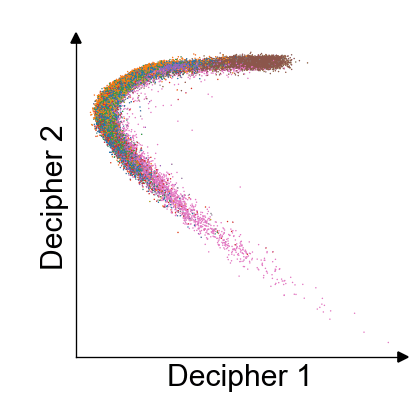

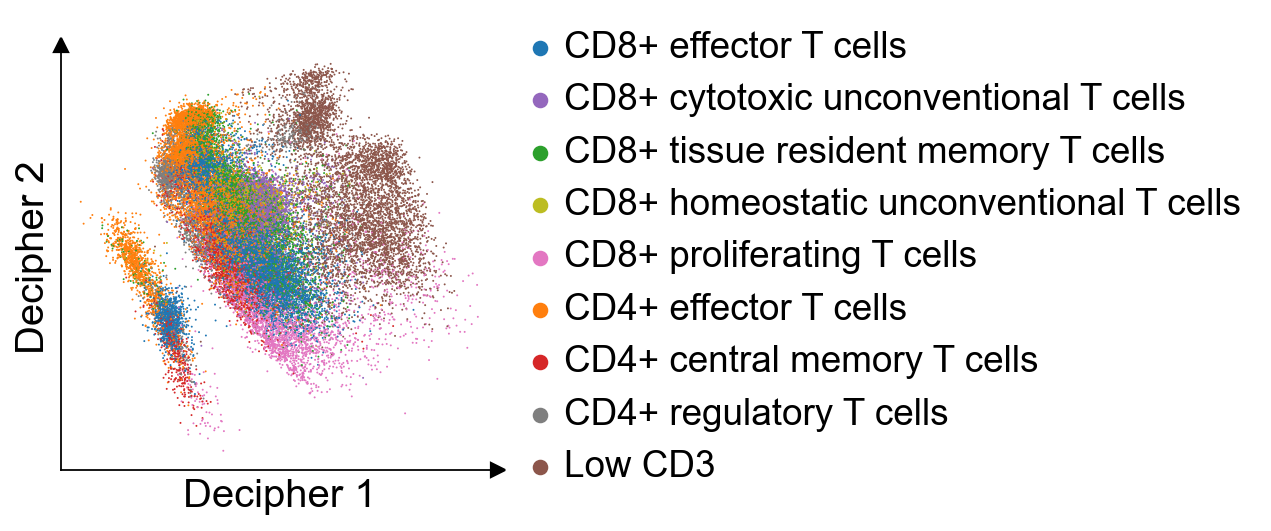

In [53]:
# Tested with good seperation on epoches 15
#decipher_config = dc.tl.DecipherConfig(n_epochs=15) # optional Decipher config

d1, val1 = dc.tl.decipher_train(
    Tcell_sc, decipher_config, plot_kwargs={"color": "T_cell_subsets", "palette": color_palette}, plot_every_k_epochs=5,
)

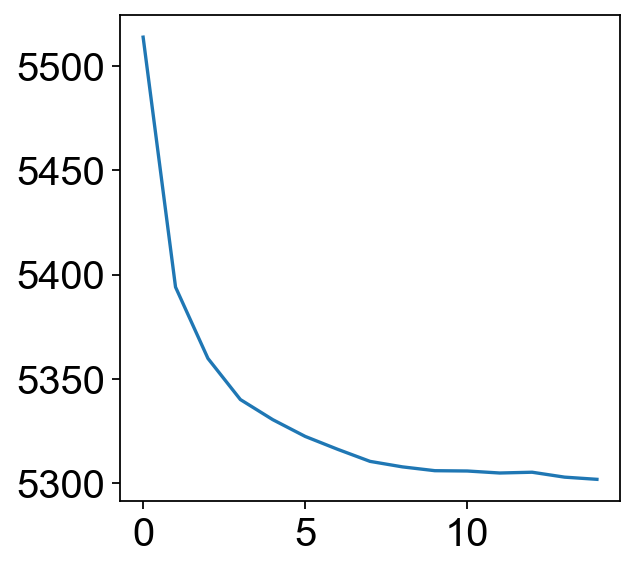

In [54]:
plt.plot(val1)

In [57]:
list(Tcell_sc.obs['PatientID'].unique())

['R096',
 'C155',
 'C152',
 'C159',
 'C162',
 'C068',
 'C101',
 'C157',
 'ND001',
 'C98',
 'R085',
 'C66',
 'C86',
 'C160',
 'C179',
 'ND003']

2026-03-03 18:48:10,169 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-03-03 18:48:10,169 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
2026-03-03 18:48:11,983 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.1.
2026-03-03 18:48:16,436 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.


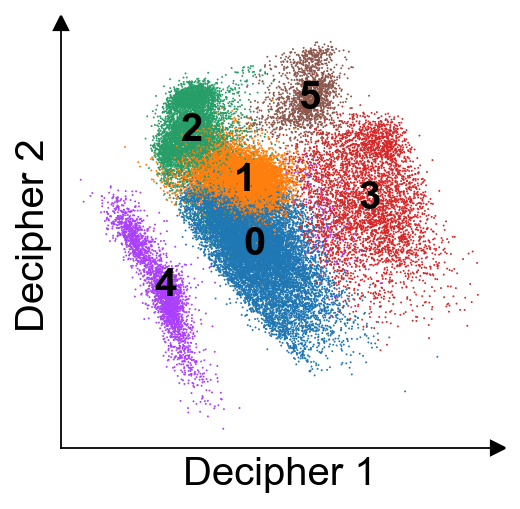

In [60]:
dc.tl.cell_clusters(Tcell_sc, leiden_resolution=0.1, n_neighbors=10, seed=0, rep_key='decipher_z')
dc.pl.decipher(Tcell_sc, ["decipher_clusters"], legend_loc="on data");

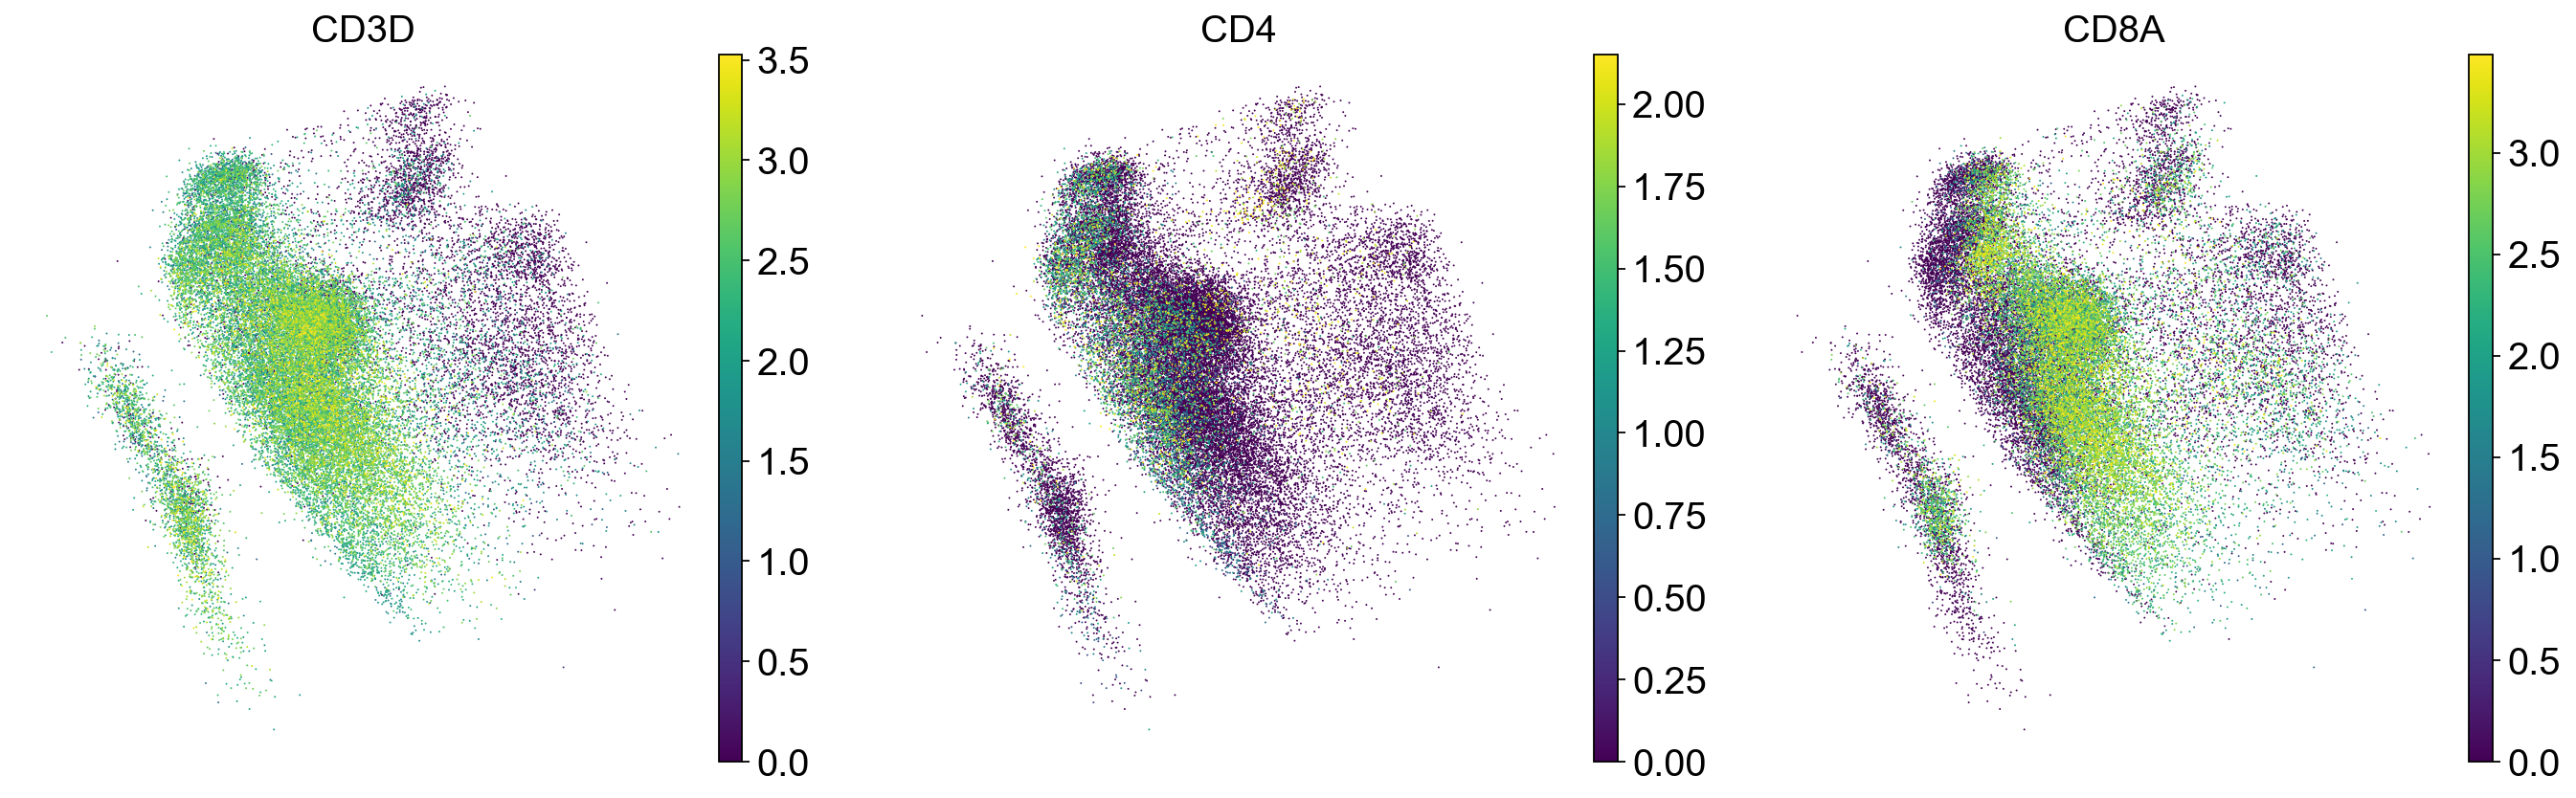

In [65]:
color=['GZMK','GZMB','TIGIT']

color=['CD3D','CD4','CD8A']

dc.pl.decipher(
    Tcell_sc,
    color,
    ncols=3,
    vmax=lambda x: np.quantile(x, 0.99),
    figsize=(6, 6),
    axis_type=None
);

In [70]:
Tcell_sc

AnnData object with n_obs × n_vars = 38815 × 38012
    obs: 'PatientID', 'SampleID', 'FreshorFrozen', 'Days_post-Transplant', 'Tissue_Location', 'LPorIE', 'Enrichment Method', 'Pathological_grade_of_GVHD', 'Grade_num', 'GVHD_Grade_1', 'GVHD_Grade_2', 'GVHD_Grade_3', 'Transplant_Conditioning', 'Gender', 'DoT', 'Time_1stGVHD', 'Donor', 'Disease', 'GVHD_Prophylaxis_Regimen', 'Dates_from_Transplantation', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'is_doublet', 'leiden', 'leiden_0.15', 'B_doublet', 'Myeloid_doublet', 'Macrophage_doublet', 'Monocyte_doublet', 'Epithelial_doublet', 'Fibroblast_doublet', 'plasma_doublet2', 'if_doublet', 'T_cell_subsets', 'decipher_split', 'decipher_z_clusters', 'decipher_clusters'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'B_doublet_colors', 'Epit

In [72]:
Tcell_sc.write(TCELL_ANN_SC_DC_PATH)